# **RAVDESS DATASET**

Ryerson Audio-Visual Database of Emotional Speech and Song

---

The dataset includes 1,440 audio files featuring 24 professional actors (12 females and 12 males). These actors performed two lexically-matched statements in a neutral North American accent, expressing eight emotions: Neutral, Calm, Happy, Sad, Angry, Fearful, Disgust, and Surprised. Each emotion was conveyed at two intensity levels (Normal and Strong), and was repeated twice by each actor to ensure consistency and reliability.

In [1]:
import pandas as pd
from scipy.io import wavfile
import seaborn as sns
import matplotlib.pyplot as plt
import parselmouth
import numpy as np
import os
import librosa
from IPython import display as ipd

%load_ext autoreload
%autoreload 2

### Data Processing

In [2]:
# Import python file/module functions.py
from data_process import DataProcess
process = DataProcess()

In [3]:
# Create DataFrame with index `File_Name`
df = pd.read_csv('audio.csv')
# df.set_index('File_Name', inplace=True)

In [4]:
# Show current DF
df.head()

,File_Name,Actor,Gender,Emotion,Intensity,Statement,Repetition
0,03-01-01-01-01-01-01.wav,1,M,neutral,normal,1,1
1,03-01-01-01-01-02-01.wav,1,M,neutral,normal,1,2
2,03-01-01-01-02-01-01.wav,1,M,neutral,normal,2,1
3,03-01-01-01-02-02-01.wav,1,M,neutral,normal,2,2
4,03-01-02-01-01-01-01.wav,1,M,calm,normal,1,1


In [5]:
gender_distribution = df.groupby(['Emotion', 'Gender']).size()
print(gender_distribution)

Emotion    Gender
angry      F         96
           M         96
calm       F         96
           M         96
disgust    F         96
           M         96
fearful    F         96
           M         96
happy      F         96
           M         96
neutral    F         48
           M         48
sad        F         96
           M         96
surprised  F         96
           M         96
dtype: int64


In [6]:
# Oversampling process

max_count = gender_distribution.max()
# Initialize balanced DataFrame
balanced_df = pd.DataFrame()

for (emotion, gender), count in gender_distribution.items():
    label_df = df[(df['Emotion'] == emotion) & (df['Gender'] == gender)]
    # Oversample if the current class has less than max_count
    if len(label_df) < max_count:
        label_df = label_df.sample(max_count, replace=True)
        
#     label_df['File Name'] = label_df.index
        
    balanced_df = pd.concat([balanced_df, label_df], ignore_index=True)

# Check the balanced DataFrame
print(balanced_df['Emotion'].value_counts())
print(balanced_df['Gender'].value_counts())

Emotion
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral      192
sad          192
surprised    192
Name: count, dtype: int64
Gender
F    768
M    768
Name: count, dtype: int64


In [7]:
balanced_df.head()

,File_Name,Actor,Gender,Emotion,Intensity,Statement,Repetition
0,03-01-05-01-01-01-02.wav,2,F,angry,normal,1,1
1,03-01-05-01-01-02-02.wav,2,F,angry,normal,1,2
2,03-01-05-01-02-01-02.wav,2,F,angry,normal,2,1
3,03-01-05-01-02-02-02.wav,2,F,angry,normal,2,2
4,03-01-05-02-01-01-02.wav,2,F,angry,strong,1,1


In [8]:
file_dir = "data/"
feature_df = process.process_data(balanced_df, file_dir)
feature_df.head()

03-01-05-01-01-01-02.wav
03-01-05-01-01-02-02.wav
03-01-05-01-02-01-02.wav
03-01-05-01-02-02-02.wav
03-01-05-02-01-01-02.wav
03-01-05-02-01-02-02.wav
03-01-05-02-02-01-02.wav
03-01-05-02-02-02-02.wav
03-01-05-01-01-01-04.wav
03-01-05-01-01-02-04.wav
03-01-05-01-02-01-04.wav
03-01-05-01-02-02-04.wav
03-01-05-02-01-01-04.wav
03-01-05-02-01-02-04.wav
03-01-05-02-02-01-04.wav
03-01-05-02-02-02-04.wav
03-01-05-01-01-01-06.wav
03-01-05-01-01-02-06.wav
03-01-05-01-02-01-06.wav
03-01-05-01-02-02-06.wav
03-01-05-02-01-01-06.wav
03-01-05-02-01-02-06.wav
03-01-05-02-02-01-06.wav
03-01-05-02-02-02-06.wav
03-01-05-01-01-01-08.wav
03-01-05-01-01-02-08.wav
03-01-05-01-02-01-08.wav
03-01-05-01-02-02-08.wav
03-01-05-02-01-01-08.wav
03-01-05-02-01-02-08.wav
03-01-05-02-02-01-08.wav
03-01-05-02-02-02-08.wav
03-01-05-01-01-01-10.wav
03-01-05-01-01-02-10.wav
03-01-05-01-02-01-10.wav
03-01-05-01-02-02-10.wav
03-01-05-02-01-01-10.wav
03-01-05-02-01-02-10.wav
03-01-05-02-02-01-10.wav
03-01-05-02-02-02-10.wav


03-01-02-02-01-02-11.wav
03-01-02-02-02-01-11.wav
03-01-02-02-02-02-11.wav
03-01-02-01-01-01-13.wav
03-01-02-01-01-02-13.wav
03-01-02-01-02-01-13.wav
03-01-02-01-02-02-13.wav
03-01-02-02-01-01-13.wav
03-01-02-02-01-02-13.wav
03-01-02-02-02-01-13.wav
03-01-02-02-02-02-13.wav
03-01-02-01-01-01-15.wav
03-01-02-01-01-02-15.wav
03-01-02-01-02-01-15.wav
03-01-02-01-02-02-15.wav
03-01-02-02-01-01-15.wav
03-01-02-02-01-02-15.wav
03-01-02-02-02-01-15.wav
03-01-02-02-02-02-15.wav
03-01-02-01-01-01-17.wav
03-01-02-01-01-02-17.wav
03-01-02-01-02-01-17.wav
03-01-02-01-02-02-17.wav
03-01-02-02-01-01-17.wav
03-01-02-02-01-02-17.wav
03-01-02-02-02-01-17.wav
03-01-02-02-02-02-17.wav
03-01-02-01-01-01-19.wav
03-01-02-01-01-02-19.wav
03-01-02-01-02-01-19.wav
03-01-02-01-02-02-19.wav
03-01-02-02-01-01-19.wav
03-01-02-02-01-02-19.wav
03-01-02-02-02-01-19.wav
03-01-02-02-02-02-19.wav
03-01-02-01-01-01-21.wav
03-01-02-01-01-02-21.wav
03-01-02-01-02-01-21.wav
03-01-02-01-02-02-21.wav
03-01-02-02-01-01-21.wav


03-01-06-01-02-02-24.wav
03-01-06-02-01-01-24.wav
03-01-06-02-01-02-24.wav
03-01-06-02-02-01-24.wav
03-01-06-02-02-02-24.wav
03-01-06-01-01-01-01.wav
03-01-06-01-01-02-01.wav
03-01-06-01-02-01-01.wav
03-01-06-01-02-02-01.wav
03-01-06-02-01-01-01.wav
03-01-06-02-01-02-01.wav
03-01-06-02-02-01-01.wav
03-01-06-02-02-02-01.wav
03-01-06-01-01-01-03.wav
03-01-06-01-01-02-03.wav
03-01-06-01-02-01-03.wav
03-01-06-01-02-02-03.wav
03-01-06-02-01-01-03.wav
03-01-06-02-01-02-03.wav
03-01-06-02-02-01-03.wav
03-01-06-02-02-02-03.wav
03-01-06-01-01-01-05.wav
03-01-06-01-01-02-05.wav
03-01-06-01-02-01-05.wav
03-01-06-01-02-02-05.wav
03-01-06-02-01-01-05.wav
03-01-06-02-01-02-05.wav
03-01-06-02-02-01-05.wav
03-01-06-02-02-02-05.wav
03-01-06-01-01-01-07.wav
03-01-06-01-01-02-07.wav
03-01-06-01-02-01-07.wav
03-01-06-01-02-02-07.wav
03-01-06-02-01-01-07.wav
03-01-06-02-01-02-07.wav
03-01-06-02-02-01-07.wav
03-01-06-02-02-02-07.wav
03-01-06-01-01-01-09.wav
03-01-06-01-01-02-09.wav
03-01-06-01-02-01-09.wav


03-01-01-01-01-01-18.wav
03-01-01-01-02-02-24.wav
03-01-01-01-02-02-06.wav
03-01-01-01-02-02-14.wav
03-01-01-01-01-01-14.wav
03-01-01-01-01-01-20.wav
03-01-01-01-01-02-18.wav
03-01-01-01-02-01-10.wav
03-01-01-01-01-01-20.wav
03-01-01-01-02-01-12.wav
03-01-01-01-01-01-20.wav
03-01-01-01-02-01-12.wav
03-01-01-01-01-01-10.wav
03-01-01-01-02-02-06.wav
03-01-01-01-01-02-18.wav
03-01-01-01-02-01-16.wav
03-01-01-01-02-01-16.wav
03-01-01-01-01-01-14.wav
03-01-01-01-01-02-08.wav
03-01-01-01-01-02-14.wav
03-01-01-01-01-02-24.wav
03-01-01-01-02-01-08.wav
03-01-01-01-01-02-24.wav
03-01-01-01-01-02-20.wav
03-01-01-01-01-01-12.wav
03-01-01-01-02-01-10.wav
03-01-01-01-02-01-16.wav
03-01-01-01-02-01-06.wav
03-01-01-01-02-02-18.wav
03-01-01-01-02-01-10.wav
03-01-01-01-02-02-22.wav
03-01-01-01-01-02-08.wav
03-01-01-01-01-01-18.wav
03-01-01-01-01-02-06.wav
03-01-01-01-01-01-16.wav
03-01-01-01-02-01-18.wav
03-01-01-01-01-01-20.wav
03-01-01-01-01-02-16.wav
03-01-01-01-01-01-10.wav
03-01-01-01-01-01-24.wav


03-01-04-01-01-02-21.wav
03-01-04-01-02-01-21.wav
03-01-04-01-02-02-21.wav
03-01-04-02-01-01-21.wav
03-01-04-02-01-02-21.wav
03-01-04-02-02-01-21.wav
03-01-04-02-02-02-21.wav
03-01-04-01-01-01-23.wav
03-01-04-01-01-02-23.wav
03-01-04-01-02-01-23.wav
03-01-04-01-02-02-23.wav
03-01-04-02-01-01-23.wav
03-01-04-02-01-02-23.wav
03-01-04-02-02-01-23.wav
03-01-04-02-02-02-23.wav
03-01-08-01-01-01-02.wav
03-01-08-01-01-02-02.wav
03-01-08-01-02-01-02.wav
03-01-08-01-02-02-02.wav
03-01-08-02-01-01-02.wav
03-01-08-02-01-02-02.wav
03-01-08-02-02-01-02.wav
03-01-08-02-02-02-02.wav
03-01-08-01-01-01-04.wav
03-01-08-01-01-02-04.wav
03-01-08-01-02-01-04.wav
03-01-08-01-02-02-04.wav
03-01-08-02-01-01-04.wav
03-01-08-02-01-02-04.wav
03-01-08-02-02-01-04.wav
03-01-08-02-02-02-04.wav
03-01-08-01-01-01-06.wav
03-01-08-01-01-02-06.wav
03-01-08-01-02-01-06.wav
03-01-08-01-02-02-06.wav
03-01-08-02-01-01-06.wav
03-01-08-02-01-02-06.wav
03-01-08-02-02-01-06.wav
03-01-08-02-02-02-06.wav
03-01-08-01-01-01-08.wav


,0,1,2,3,4,5,6,7,8,9,10,11,12,Emotion,Gender
0,-527.771973,84.746284,-13.713666,6.152499,-2.844437,-0.334177,-14.337663,3.791651,-15.808460,-7.214999,-4.625344,-3.479475,-4.090996,angry,F
1,-489.296600,86.032768,-22.118237,4.226904,-2.079272,-2.259366,-14.940624,3.359568,-18.336355,-4.102755,-3.368579,-1.079819,-2.875202,angry,F
2,-517.161194,89.020744,-15.689508,7.021028,-8.726629,-0.807260,-16.223230,4.902808,-20.622217,-5.785514,-8.389670,-1.289762,-9.433119,angry,F
3,-501.960876,86.239189,-22.163244,5.212844,-8.762463,-3.512598,-20.345150,5.690538,-22.433388,-6.798852,-8.197632,-2.386638,-8.318398,angry,F
4,-397.130035,76.664711,-36.456913,0.023763,-8.202541,-12.249104,-19.687902,5.640836,-20.901567,-9.836579,-2.697503,-7.851609,-5.597193,angry,F


In [10]:
X, y, X_train, X_test, y_train, y_test = process.split_data(feature_df)

### Decision Tree

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [11]:
# Model Preparation
clf = DecisionTreeClassifier(random_state=42)

In [12]:
# Train the model
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [13]:
# Test the model
y_pred = clf.predict(X_test)

In [14]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Results
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)

Accuracy: 0.38
Classification Report:
              precision    recall  f1-score   support

       angry       0.59      0.48      0.53        42
        calm       0.57      0.45      0.51        44
     disgust       0.36      0.44      0.39        32
     fearful       0.28      0.34      0.31        32
       happy       0.33      0.38      0.35        34
     neutral       0.28      0.25      0.26        20
         sad       0.26      0.31      0.28        39
   surprised       0.39      0.31      0.35        45

    accuracy                           0.38       288
   macro avg       0.38      0.37      0.37       288
weighted avg       0.40      0.38      0.38       288



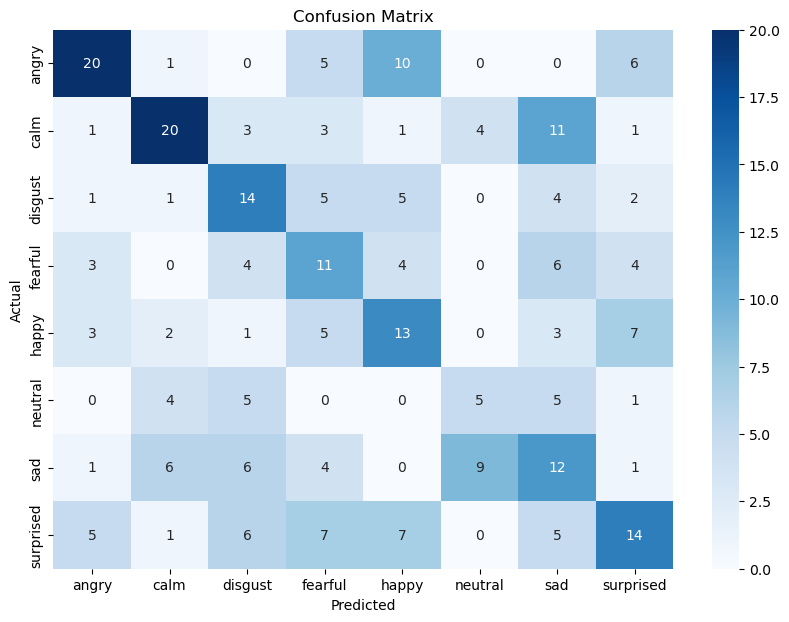

In [15]:
process.show_cmatrix(y_test, y_pred, y)

### Support Vector Machine

In [16]:
from sklearn.svm import SVC

In [17]:
# Initialize the SVM classifier
svm_classifier = SVC(kernel='linear', random_state=42)

In [18]:
# Train the classifier
svm_classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [19]:
# Predict on the test set
y_pred = svm_classifier.predict(X_test)

In [20]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Output the results
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)

Accuracy: 0.45
Classification Report:
              precision    recall  f1-score   support

       angry       0.75      0.64      0.69        42
        calm       0.43      0.75      0.55        44
     disgust       0.39      0.47      0.43        32
     fearful       0.41      0.50      0.45        32
       happy       0.46      0.38      0.42        34
     neutral       0.20      0.05      0.08        20
         sad       0.36      0.33      0.35        39
   surprised       0.37      0.24      0.29        45

    accuracy                           0.45       288
   macro avg       0.42      0.42      0.41       288
weighted avg       0.44      0.45      0.43       288



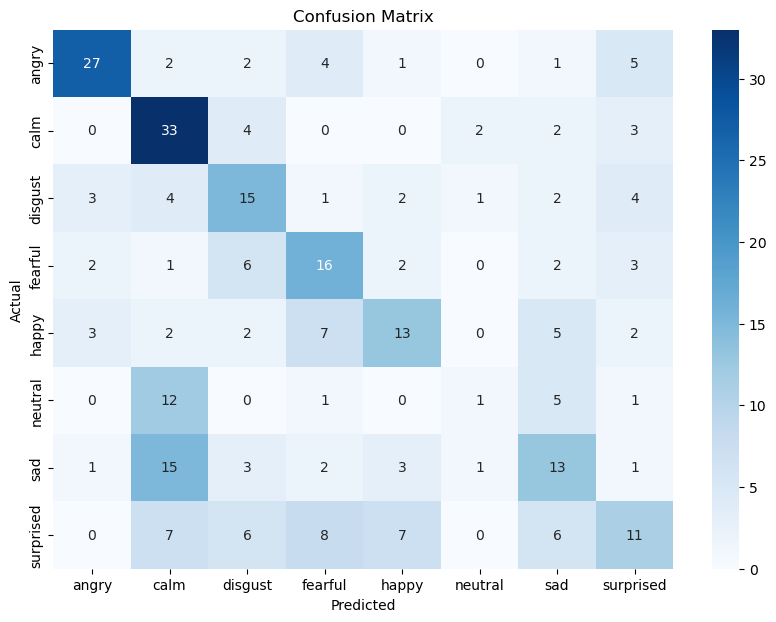

In [21]:
process.show_cmatrix(y_test, y_pred, y)

### Convolutional Neural Network

In [ ]:
# Data Preprocessing, Feature Extraction
# Model Preparation
# Model Training
# Evaluation

In [ ]:
file_dir = "data/"
feature_df = process.process_data_cnn(df, file_dir)
feature_df.head()

### Notes

Lok, E. J. (2019). Audio Emotion | Part 1 - Explore data. Kaggle. https://www.kaggle.com/code/ejlok1/audio-emotion-part-1-explore-data 

Lok, E. J. (2019). Audio Emotion | Part 2 - Feature Extract. Kaggle. https://www.kaggle.com/code/ejlok1/audio-emotion-part-2-feature-extract 

Burnwal, S. (2020). Speech emotion recognition. Kaggle. https://www.kaggle.com/code/shivamburnwal/speech-emotion-recognition/notebook 

Clariño, M. A. A. D., & Alfonso, M. M. (2016). Evaluation of speech emotion recognition based on support vector machines with Gaussian mixture model super vectors1. Journal of Science, Technology, and Arts Research, 3, 25-34. https://national-u.edu.ph/wp-content/uploads/2016/08/JSTAR-3_Clarino.pdf 

,Actor,Gender,Emotion,Intensity,Statement,Repetition,length
File_Name,,,,,,,
03-01-05-01-01-01-02.wav,2,F,angry,normal,1,1,3.670333
03-01-05-01-01-02-02.wav,2,F,angry,normal,1,2,3.670333
03-01-05-01-02-01-02.wav,2,F,angry,normal,2,1,3.770417
03-01-05-01-02-02-02.wav,2,F,angry,normal,2,2,3.803792
03-01-05-02-01-01-02.wav,2,F,angry,strong,1,1,3.903917
03-01-05-02-01-02-02.wav,2,F,angry,strong,1,2,4.004000
03-01-05-02-02-01-02.wav,2,F,angry,strong,2,1,4.004000
03-01-05-02-02-02-02.wav,2,F,angry,strong,2,2,4.004000
03-01-05-01-01-01-04.wav,4,F,angry,normal,1,1,3.703708


In [37]:
balanced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2962 entries, 0 to 03-01-08-02-02-02-23.wav
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   File_Name   1536 non-null   object 
 1   Actor       1536 non-null   float64
 2   Gender      1536 non-null   object 
 3   Emotion     1536 non-null   object 
 4   Intensity   1536 non-null   object 
 5   Statement   1536 non-null   float64
 6   Repetition  1536 non-null   float64
 7   length      1426 non-null   float64
dtypes: float64(4), object(4)
memory usage: 272.8+ KB


In [12]:
df.tail(20)

,Actor,Gender,Emotion,Intensity,Statement,Repetition
File_Name,,,,,,
03-01-06-02-01-01-24.wav,24,F,fearful,strong,1,1
03-01-06-02-01-02-24.wav,24,F,fearful,strong,1,2
03-01-06-02-02-01-24.wav,24,F,fearful,strong,2,1
03-01-06-02-02-02-24.wav,24,F,fearful,strong,2,2
03-01-07-01-01-01-24.wav,24,F,disgust,normal,1,1
03-01-07-01-01-02-24.wav,24,F,disgust,normal,1,2
03-01-07-01-02-01-24.wav,24,F,disgust,normal,2,1
03-01-07-01-02-02-24.wav,24,F,disgust,normal,2,2
03-01-07-02-01-01-24.wav,24,F,disgust,strong,1,1
